In [1]:
# All Newman-alpha-scheme machinery (centering, Jacobians, LCF/spectral-gap
# computation, sync/async updates, MLE fitting, SBM data generation) now
# lives in utils.py -- see that file for full documentation of each function.
# utils.py must be in the same directory as this notebook (or on sys.path).
from utils import *

import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.colors import to_rgb, to_hex
from matplotlib.lines import Line2D

# Bipartite

In [2]:
# ── Setup (shared by the error-history plot and the convergence-factor plot) ──
n     = 500
L     = 10
p     = 0
q     = 0.5
sigma = 0.5
size  = (16, 13.6)   # figure size for the error-history plot

A = sbm_2block(n, p, q, seed=2026)

rng        = np.random.default_rng(366)
gamma_true = rng.lognormal(0, sigma, n)
gamma_true = centering(gamma_true)
W, win_list, loss_list, mle = get_data(A, L, gamma_true)

rng_ind   = np.random.default_rng(42)
index_new = rng_ind.permutation(n)   # random ordering used for the async (rand) curves

## Convergence history (error)

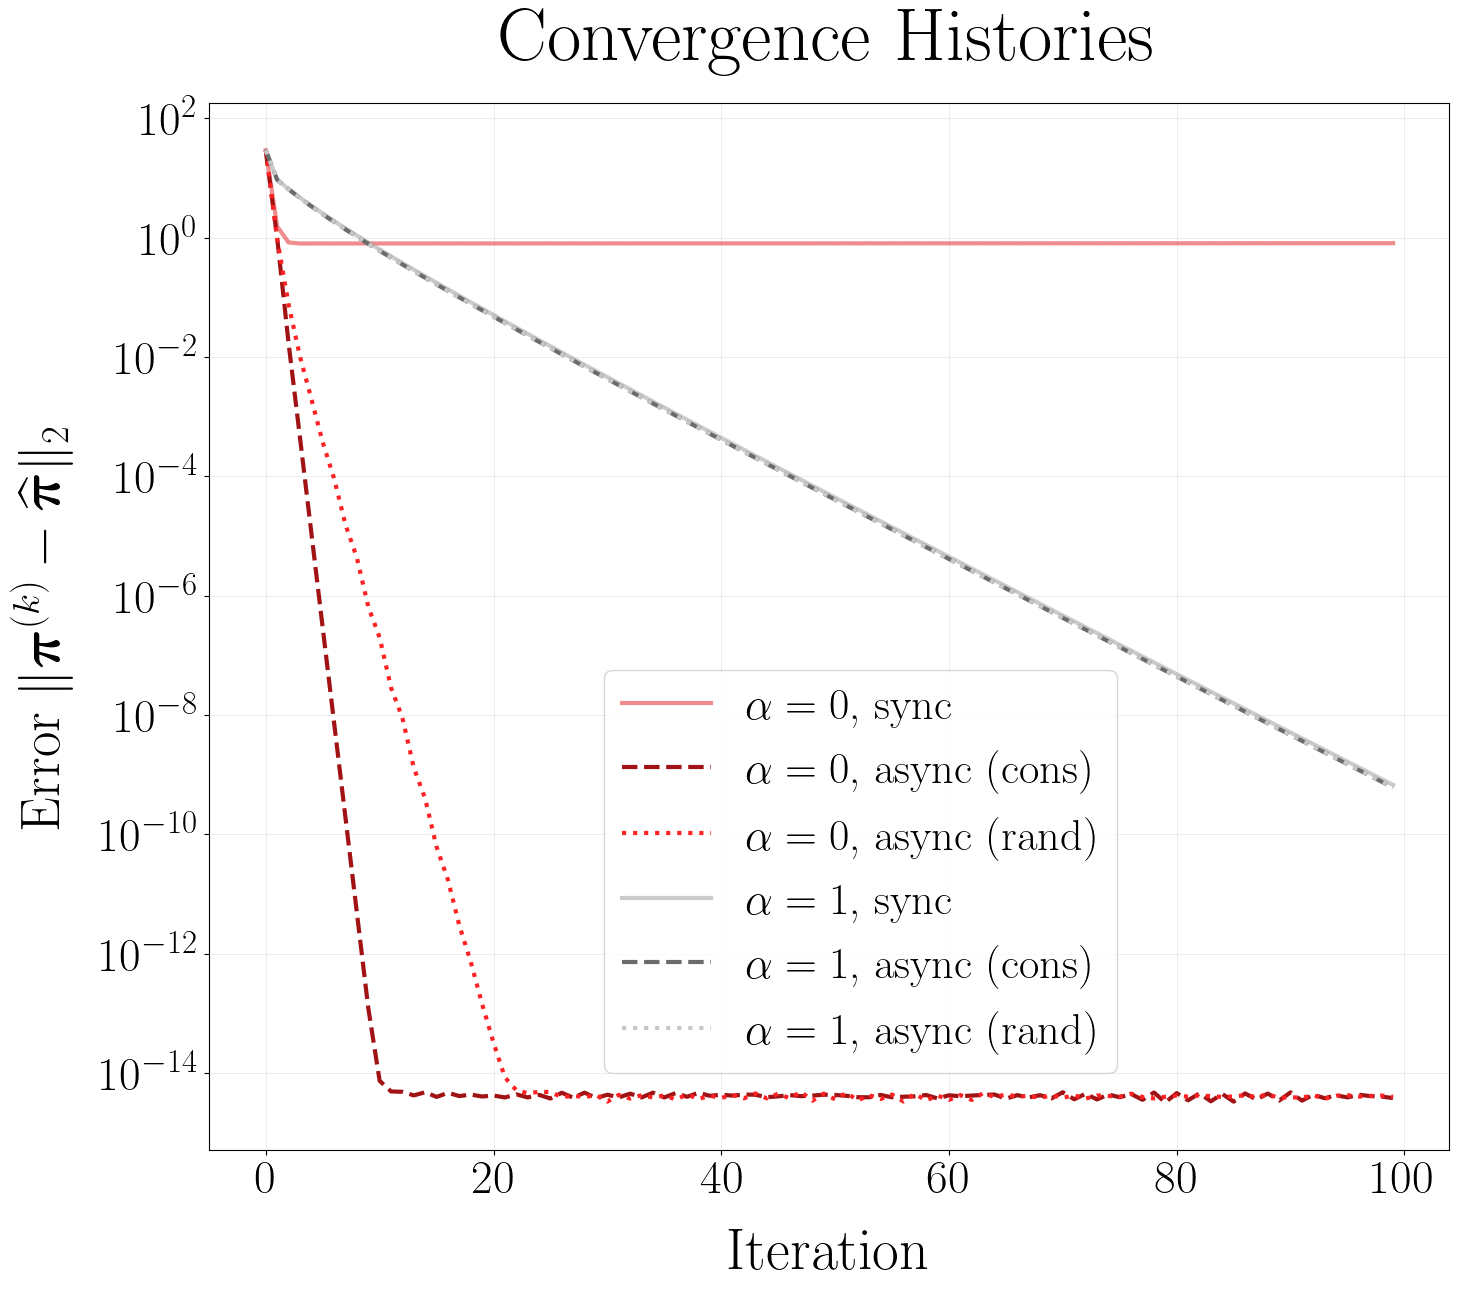

In [3]:
N = 100
alphas = [0, 1]
base_colors = plt.cm.Set1(np.linspace(0, 1, len(alphas)))   # base color per alpha

def shade_color(color, factor):
    # lighter/darker shade of color (factor <1 darker, >1 lighter)
    r, g, b = to_rgb(color)
    r = min(max(r*factor, 0), 1)
    g = min(max(g*factor, 0), 1)
    b = min(max(b*factor, 0), 1)
    return (r, g, b)

rc('text', usetex=True)
rc('font', family='serif')
rc('text.latex', preamble=r'\usepackage{bm}')   # needed for \bm{} in the y-axis label below

plt.figure(figsize=size)

for i, a in enumerate(alphas):
    # ---- sync (cons) ----
    gamma = np.ones(n) / n
    error_sync = []
    for _ in range(N):
        error_sync.append(np.linalg.norm(gamma - mle, ord=2))
        gamma = newman_update(gamma, win_list, loss_list, alpha=a, sync='full')
    plt.semilogy(error_sync,
                 color=base_colors[i], linewidth=3, linestyle='-', alpha=0.5,
                 label=rf"$\alpha={a}$, sync")

    # ---- async (cons) ----
    gamma = np.ones(n) / n
    error_async = []
    for _ in range(N):
        error_async.append(np.linalg.norm(gamma - mle, ord=2))
        gamma = newman_update(gamma, win_list, loss_list, alpha=a, sync='none')
    plt.semilogy(error_async,
                 color=shade_color(base_colors[i], 0.7), linewidth=3, linestyle='--',
                 label=rf"$\alpha={a}$, async (cons)")

    # ---- async (rand) ----
    gamma = np.ones(n) / n
    error_gs = []
    for _ in range(N):
        error_gs.append(np.linalg.norm(gamma - mle, ord=2))
        gamma = newman_update(gamma, win_list, loss_list, alpha=a, w=1, sync='none', index=index_new)
    plt.semilogy(error_gs,
                 color=shade_color(base_colors[i], 1.3), linewidth=3, linestyle=':',
                 label=rf"$\alpha={a}$, async (rand)")


plt.title(r"$\mathrm{Convergence \ Histories}$", fontsize=54, color='black', pad=30)
plt.grid(True, linewidth=0.4, alpha=0.4)
plt.xlabel(r'Iteration', fontsize=42, labelpad=20)
# --- Referee comment: unify y-axis label across figures ---
plt.ylabel(r'Error $\|\bm{\pi}^{(k)}-\widehat{\bm{\pi}}\|_2$', fontsize=40, labelpad=20)
plt.tick_params(axis='both', which='major', labelsize=34)
plt.legend(fontsize=32, loc='upper right', bbox_to_anchor=(0.75, 0.48))
plt.savefig("nonconvergence_hist.pdf", bbox_inches='tight')
plt.show()

## Convergence factor vs $\alpha$

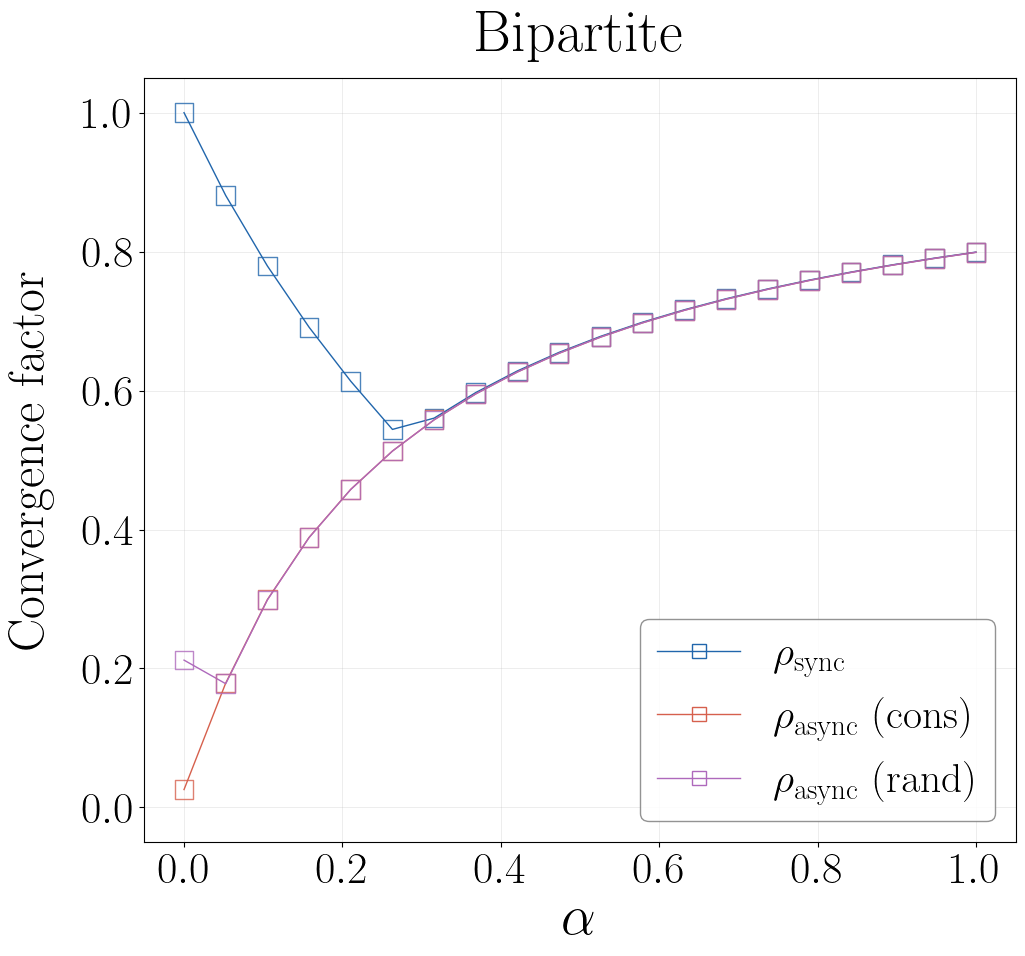

In [4]:
# --- Shared style config ---
FIG_W, FIG_H  = 10.2, 9.5
TITLE_FS      = 50
LABEL_FS      = 40
TICK_FS       = 32
LEGEND_FS     = 30
MARKER_S      = 180

COLOR_SYNC     = '#2166AC'   # blue   -- sync
COLOR_ASYNC    = '#D6604D'   # red    -- async, consistent ordering
COLOR_ASYNC_R  = '#AE69BC'   # purple -- async, random ordering

rc('text', usetex=True)
rc('font', family='serif')
rc('axes', linewidth=0.8)

alpha_set = np.linspace(0, 1, 20)

# Permuted system for the random-ordering Gauss-Seidel rate
Wp   = W[index_new][:, index_new]
mlep = mle[index_new]

# Observed rates (spectral radius of the Jacobian / GS operator)
rates_f  = np.array([get_lcf(W,  mle,  alpha, sync='full') for alpha in alpha_set])
rates_a  = np.array([get_lcf(W,  mle,  alpha, sync='none') for alpha in alpha_set])
rates_ar = np.array([get_lcf(Wp, mlep, alpha, sync='none') for alpha in alpha_set])

# Predicted rates (1 - spectral gap)
ratesbar_f  = np.array([1 - get_gap(W,  mle,  alpha, sync='full') for alpha in alpha_set])
ratesbar_a  = np.array([1 - get_gap(W,  mle,  alpha, sync='none') for alpha in alpha_set])
ratesbar_ar = np.array([1 - get_gap(Wp, mlep, alpha, sync='none') for alpha in alpha_set])

# ---------- plot ----------
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

for rho, col in [
    (rates_f,  COLOR_SYNC),
    (rates_a,  COLOR_ASYNC),
    (rates_ar, COLOR_ASYNC_R),
]:
    # observed rho -- hollow square, solid line
    ax.scatter(alpha_set, rho, color=col, s=MARKER_S, marker='s',
               zorder=3, alpha=0.8, facecolors='none')
    ax.plot(alpha_set, rho, color=col, linewidth=1, zorder=2)

ax.set_title(r'$\mathrm{Bipartite}$', fontsize=TITLE_FS-8, pad=20)
ax.set_xlabel(r'$\alpha$', fontsize=LABEL_FS)
# --- Referee comment: unify y-axis label from 'Rate' to 'Convergence factor' ---
ax.set_ylabel(r'Convergence factor', fontsize=LABEL_FS-4, labelpad=20)
plt.ylim(-0.05, 1.05)
ax.tick_params(axis='both', which='major', labelsize=TICK_FS)
ax.grid(True, linewidth=0.4, alpha=0.4)

legend_elements = [
    Line2D([0], [0], color=COLOR_SYNC,    marker='s', markersize=10,
           markerfacecolor='none', markeredgecolor=COLOR_SYNC,
           linestyle='-', linewidth=1, label=r'$\rho_{\mathrm{sync}}$'),
    Line2D([0], [0], color=COLOR_ASYNC,   marker='s', markersize=10,
           markerfacecolor='none', markeredgecolor=COLOR_ASYNC,
           linestyle='-', linewidth=1, label=r'$\rho_{\mathrm{async}}\ (\mathrm{cons})$'),
    Line2D([0], [0], color=COLOR_ASYNC_R, marker='s', markersize=10,
           markerfacecolor='none', markeredgecolor=COLOR_ASYNC_R,
           linestyle='-', linewidth=1, label=r'$\rho_{\mathrm{async}}\ (\mathrm{rand})$'),
]
ax.legend(handles=legend_elements, fontsize=LEGEND_FS, loc='lower right',
          framealpha=0.85, edgecolor='gray')

plt.tight_layout(pad=0.5)
plt.savefig('nonconvergence.pdf', bbox_inches='tight', dpi=300)
plt.show()

## Get rates

In [ ]:
gap_gs = get_gap(W, mle, alpha=0, sync='none')
gap_gs_r = get_gap(W[index_new][:,index_new], mle, alpha=0, sync='none')
gap_f = get_gap(W, mle, alpha=1, sync='full')
print(np.log10(1-gap_gs)/np.log10(1-gap_f), np.log10(1-gap_gs_r)/np.log10(1-gap_f))

In [ ]:
np.sort(get_spectral_gap(W, mle)[1])[::-1][1]